# Untersuchung von SMA-Marktregimen beim S&P 500
Anwendungs auf zunächst einen Index -> Anschließend Übertragung auf weitere Indizes 

## Forschungsfrage: 

Unterscheiden sich die zukünftigen 1-, 5- und 20-Handelstage-Renditen des S&P 500 zwischen einem positiven und einem negativen SMA-20/50-Regime?

## Hypothesen:

H0: Die zukünftigen Renditen unterscheiden sich nicht zwischen
dem positiven und dem negativen SMA-Regime.

H1: Die zukünftigen Renditen unterscheiden sich zwischen
dem positiven und dem negativen SMA-Regime.

## Marktregime

Positives Regime:
SMA 20 > SMA 50

Negatives Regime:
SMA 20 <= SMA 50

## Untersuchungszeitraum

1. Januar 2010 bis zum aktuell verfügbaren Handelstag.

## Prognosehorizonte

- 1 Handelstag
- 5 Handelstage
- 20 Handelstage

### 1. Arbeitsschritt: Bibliotheken importieren

In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import yfinance as yf
import scipy

from scipy.stats import mannwhitneyu, ttest_ind    ## bietet wissenschaftliche Funktionen, etwa für Statistik, Optimierung und Signalverarbeitung


pd.set_option("display.max_columns", 30)     ## Anzeige des Panda DataFrames in max. 30 Spalten
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")     ## Festlegung Anzeige Fließkommazahlen 

print("Bibliotheken erfolgreich importiert.")


## Welche Versionen werden verwendet - evtl. für Bericht o.ä. relevant 

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("yfinance:", yf.__version__)
print("scipy:", scipy.__version__)
print("matplotlib:", matplotlib.__version__)

Bibliotheken erfolgreich importiert.
pandas: 3.0.3
numpy: 2.4.4
yfinance: 1.5.2
scipy: 1.17.1
matplotlib: 3.10.9


### 2. Arbeitsschritt: Daten laden

In [2]:
TICKER = "^GSPC"
START_DATE = "2010-01-01"

raw = yf.download(
    TICKER,
    start=START_DATE,
    interval="1d",
    auto_adjust=True,
    progress=False,
    multi_level_index=False,
)

print(raw.head())
print()
print(raw.tail())
print()
print("Zeilen und Spalten:", raw.shape)

                  Close         High          Low         Open      Volume
Date                                                                      
2010-01-04 1,132.989990 1,133.869995 1,116.560059 1,116.560059  3991400000
2010-01-05 1,136.520020 1,136.630005 1,129.660034 1,132.660034  2491020000
2010-01-06 1,137.140015 1,139.189941 1,133.949951 1,135.709961  4972660000
2010-01-07 1,141.689941 1,142.459961 1,131.319946 1,136.270020  5270680000
2010-01-08 1,144.979980 1,145.390015 1,136.219971 1,140.520020  4389590000

                  Close         High          Low         Open      Volume
Date                                                                      
2026-07-27 7,413.180176 7,480.569824 7,382.740234 7,464.200195  5038290000
2026-07-28 7,428.779785 7,452.089844 7,382.950195 7,395.549805  5590890000
2026-07-29 7,316.149902 7,450.839844 7,313.919922 7,418.160156  5836350000
2026-07-30 7,437.629883 7,448.750000 7,370.979980 7,390.450195  5594430000
2026-07-31 7,489.720215 

### 3. Arbeitsschritt: Prüfung der Daten 

In [3]:
if raw.empty:
    raise ValueError("Der Datenabruf hat keine Daten geliefert.")

required_columns = {"Open", "High", "Low", "Close"}

missing_columns = required_columns.difference(raw.columns)

if missing_columns:
    raise ValueError(
        f"Folgende erforderliche Spalten fehlen: {missing_columns}"
    )

print("Datenabruf erfolgreich.")
print("Erstes Datum:", raw.index.min())
print("Letztes Datum:", raw.index.max())
print("Anzahl Beobachtungen:", len(raw))

Datenabruf erfolgreich.
Erstes Datum: 2010-01-04 00:00:00
Letztes Datum: 2026-07-31 00:00:00
Anzahl Beobachtungen: 4169


In [4]:
raw.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 4169 entries, 2010-01-04 to 2026-07-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   4169 non-null   float64
 1   High    4169 non-null   float64
 2   Low     4169 non-null   float64
 3   Open    4169 non-null   float64
 4   Volume  4169 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 195.4 KB


In [5]:
missing_values = raw.isna().sum().to_frame("missing_values")
missing_values["missing_percent"] = (
    missing_values["missing_values"] / len(raw) * 100
)

missing_values

,missing_values,missing_percent
Close,0,0.000000
High,0,0.000000
Low,0,0.000000
Open,0,0.000000
Volume,0,0.000000


In [6]:
print("Doppelte Datumswerte:", raw.index.duplicated().sum())
print("Chronologisch sortiert:", raw.index.is_monotonic_increasing)

Doppelte Datumswerte: 0
Chronologisch sortiert: True


### 4. Arbeitsschritt: Erstellung Data-Frame für Analyse

In [7]:
# Betrachtung Schlusskurs

df = raw[["Close"]].copy()
df = df.rename(columns={"Close": "close"})
df = df.sort_index()

print(df.head())
print(df.tail())

                  close
Date                   
2010-01-04 1,132.989990
2010-01-05 1,136.520020
2010-01-06 1,137.140015
2010-01-07 1,141.689941
2010-01-08 1,144.979980
                  close
Date                   
2026-07-27 7,413.180176
2026-07-28 7,428.779785
2026-07-29 7,316.149902
2026-07-30 7,437.629883
2026-07-31 7,489.720215


In [8]:
# Speicherung Kopie der Rohadten 

df.to_csv("sp500_raw_prices.csv")

### 5. Arbeitsschritt: Berechnung einfache Rendite

#### Tägliche einfache Rendite:

$$R_t = \frac{P_t}{P_t-1} - 1$$ 

In [9]:
# retunrn_1d = Rendite über einen Tag; pct_change() berechnete oben dargestellte Formel 

df["return_1d"] = df["close"].pct_change()

In [13]:
# falls benötigt auch noch die logarithmische Rendite // einfach Renditen werden über mehrere Zeiträume multipliziert, log Renditen können addiert werden 

df["log_return_1d"] = np.log(df["close"]).diff()

In [14]:
df.head()

,close,return_1d,log_return_1d
Date,,,
2010-01-04,"1,132.989990",NaN,NaN
2010-01-05,"1,136.520020",0.003116,0.003111
2010-01-06,"1,137.140015",0.000546,0.000545
2010-01-07,"1,141.689941",0.004001,0.003993
2010-01-08,"1,144.979980",0.002882,0.002878


### 6. Arbeitsschritt: SMA 20 und SMA 50 berechnen 

#### Einfacher gleitender Durchschnitt:

$$SMA_{n,t} = \frac{1}{n} \sum_{i=0}^{n-1} P_{t-i}$$

In [16]:
df["sma_20"] = df["close"].rolling(window=20).mean()
df["sma_50"] = df["close"].rolling(window=50).mean()

In [18]:
# Pandas gibt bei einem 20-Tage-Fenster erst nach 20 Beobachtungen Werte zurück. Bei SMA 50 entsprechend nach 50 Beobachtungen.

df[["close", "sma_20", "sma_50"]].head(55)

,close,sma_20,sma_50
Date,,,
2010-01-04,"1,132.989990",NaN,NaN
2010-01-05,"1,136.520020",NaN,NaN
2010-01-06,"1,137.140015",NaN,NaN
2010-01-07,"1,141.689941",NaN,NaN
2010-01-08,"1,144.979980",NaN,NaN
2010-01-11,"1,146.979980",NaN,NaN
2010-01-12,"1,136.219971",NaN,NaN
2010-01-13,"1,145.680054",NaN,NaN
2010-01-14,"1,148.459961",NaN,NaN


In [19]:
# Ausgabe der ersten gültigen Werte

print("Erster gültiger SMA 20:", df["sma_20"].first_valid_index())
print("Erster gültiger SMA 50:", df["sma_50"].first_valid_index())

Erster gültiger SMA 20: 2010-02-01 00:00:00
Erster gültiger SMA 50: 2010-03-16 00:00:00


### 7. Arbeitsschritt: Definition Marktregime

In [22]:
# Definition der erklärenden Variable

df["regime"] = np.where(
    df["sma_20"] > df["sma_50"],
    "positiv",
    "negativ",
)

# können es auch numerisch umsetzen -> z.B. 1 = SMA 20 größer SMA 50, 0 = SMA 20 kleiner SMA 50
# df["regime_positive"] = (
#    df["sma_20"] > df["sma_50"]
#).astype(int)

In [27]:
# für fehlende Werte aus SMA 20 und SMA 50 regime-Werte ebenfalls entfernen

df.loc[
    df[["sma_20", "sma_50"]].isna().any(axis=1),
    ["regime", "regime_positive"],
] = np.nan

In [28]:
df[["close", "sma_20", "sma_50", "regime"]].head(55)

,close,sma_20,sma_50,regime
Date,,,,
2010-01-04,"1,132.989990",NaN,NaN,NaN
2010-01-05,"1,136.520020",NaN,NaN,NaN
2010-01-06,"1,137.140015",NaN,NaN,NaN
2010-01-07,"1,141.689941",NaN,NaN,NaN
2010-01-08,"1,144.979980",NaN,NaN,NaN
2010-01-11,"1,146.979980",NaN,NaN,NaN
2010-01-12,"1,136.219971",NaN,NaN,NaN
2010-01-13,"1,145.680054",NaN,NaN,NaN
2010-01-14,"1,148.459961",NaN,NaN,NaN


### 8. Arbeitsschritt: Berechnung zukünftiger Rendite

#### Zukünftige Rendite zum Zeitpunkt t:  

$$R_{t,t+5} = \frac{P_{t+5}}{P_t} - 1$$

In [31]:
for horizon in [1, 5, 20]:
    df[f"future_return_{horizon}d"] = (
        df["close"].shift(-horizon) / df["close"] - 1
    )

In [34]:
# fehlende Werte resultieren daraus, dass für die Formel Kurse benötigt werden, die fünf bzw. 20 Handelstage in der Zukunft liegen. Am Ende des Datensatzes gibt es diese Kurse nicht mehr. Daher ist die Berechnung nicht möglich

df[
    [
        "close",
        "regime",
        "future_return_1d",
        "future_return_5d",
        "future_return_20d",
    ]
].tail(25)

,close,regime,future_return_1d,future_return_5d,future_return_20d
Date,,,,,
2026-06-26,"7,354.020020",positiv,0.011750,0.024940,0.008045
2026-06-29,"7,440.430176",positiv,0.007920,0.008524,-0.001566
2026-06-30,"7,499.359863",positiv,-0.002151,-0.002220,-0.024430
2026-07-01,"7,483.229980",positiv,0.000001,0.008073,-0.006094
2026-07-02,"7,483.240234",positiv,0.007242,0.012314,0.000866
2026-07-06,"7,537.430176",positiv,-0.004455,-0.002931,NaN
2026-07-07,"7,503.850098",positiv,-0.002817,0.005296,NaN
2026-07-08,"7,482.709961",positiv,0.008143,0.011986,NaN
2026-07-09,"7,543.640137",positiv,0.004209,-0.001308,NaN


### 9. Arbeitsschritt: Erstellung Analysedatensatz

In [35]:
analysis_df = df.dropna(
    subset=[
        "sma_20",
        "sma_50",
        "regime",
        "future_return_1d",
        "future_return_5d",
        "future_return_20d",
    ]
).copy()

print("Beobachtungen im Analysedatensatz:", len(analysis_df))
print(analysis_df.head())

Beobachtungen im Analysedatensatz: 4100
                  close  return_1d  log_return_1d       sma_20       sma_50  \
Date                                                                          
2010-03-16 1,159.459961   0.007779       0.007749 1,123.997491 1,113.826594   
2010-03-17 1,166.209961   0.005822       0.005805 1,127.332489 1,114.490994   
2010-03-18 1,165.829956  -0.000326      -0.000326 1,130.286487 1,115.077192   
2010-03-19 1,159.900024  -0.005086      -0.005099 1,132.822986 1,115.532393   
2010-03-22 1,165.810059   0.005095       0.005082 1,135.712988 1,116.014795   

             regime  regime_positive  future_return_1d  future_return_5d  \
Date                                                                       
2010-03-16  positiv              NaN          0.005822          0.012687   
2010-03-17  positiv              NaN         -0.000326          0.001295   
2010-03-18  positiv              NaN         -0.005086         -0.000086   
2010-03-19  positiv       

In [37]:
# Überprüfung der Regimeverteilung

regime_counts = analysis_df["regime"].value_counts()
regime_percent = (
    analysis_df["regime"].value_counts(normalize=True) * 100
)

regime_distribution = pd.concat(
    [
        regime_counts.rename("observations"),
        regime_percent.rename("percent"),
    ],
    axis=1,
)

regime_distribution

,observations,percent
regime,,
positiv,2892,70.536585
negativ,1208,29.463415


### 10. Arbeitsschritt: Visualisierung von Kurs und SMAs

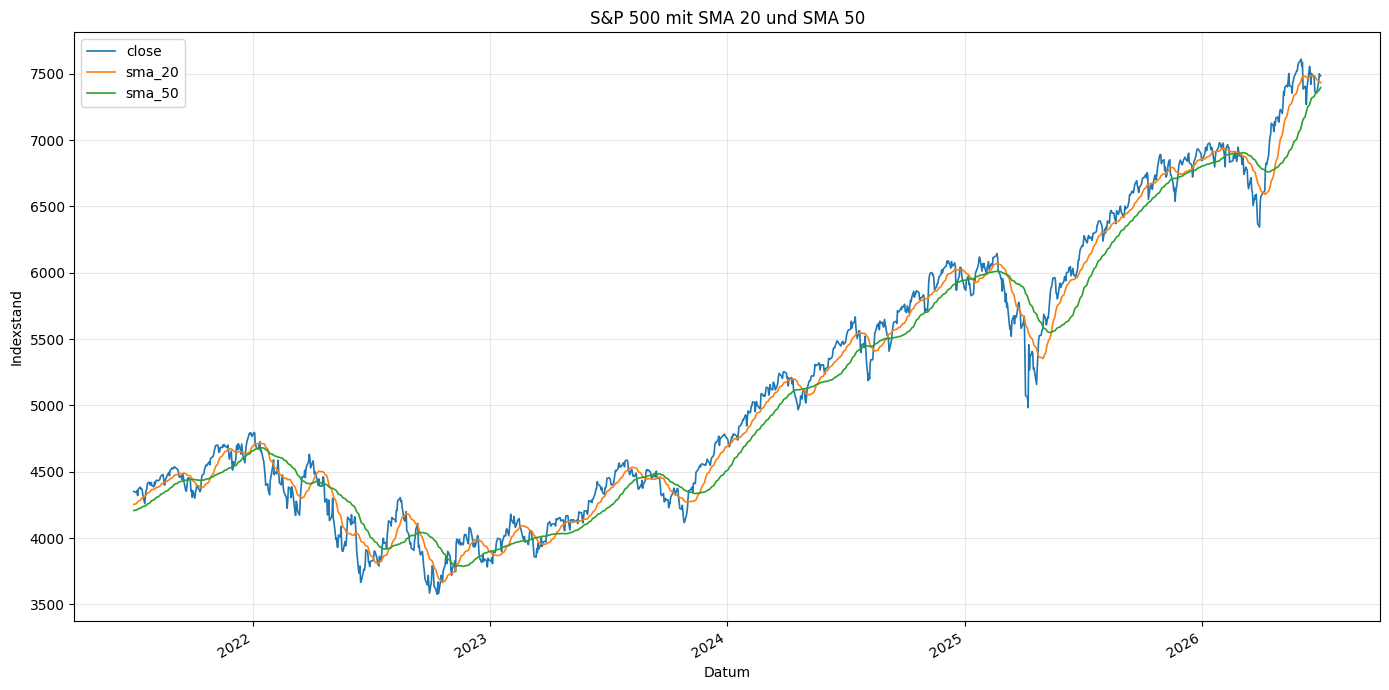

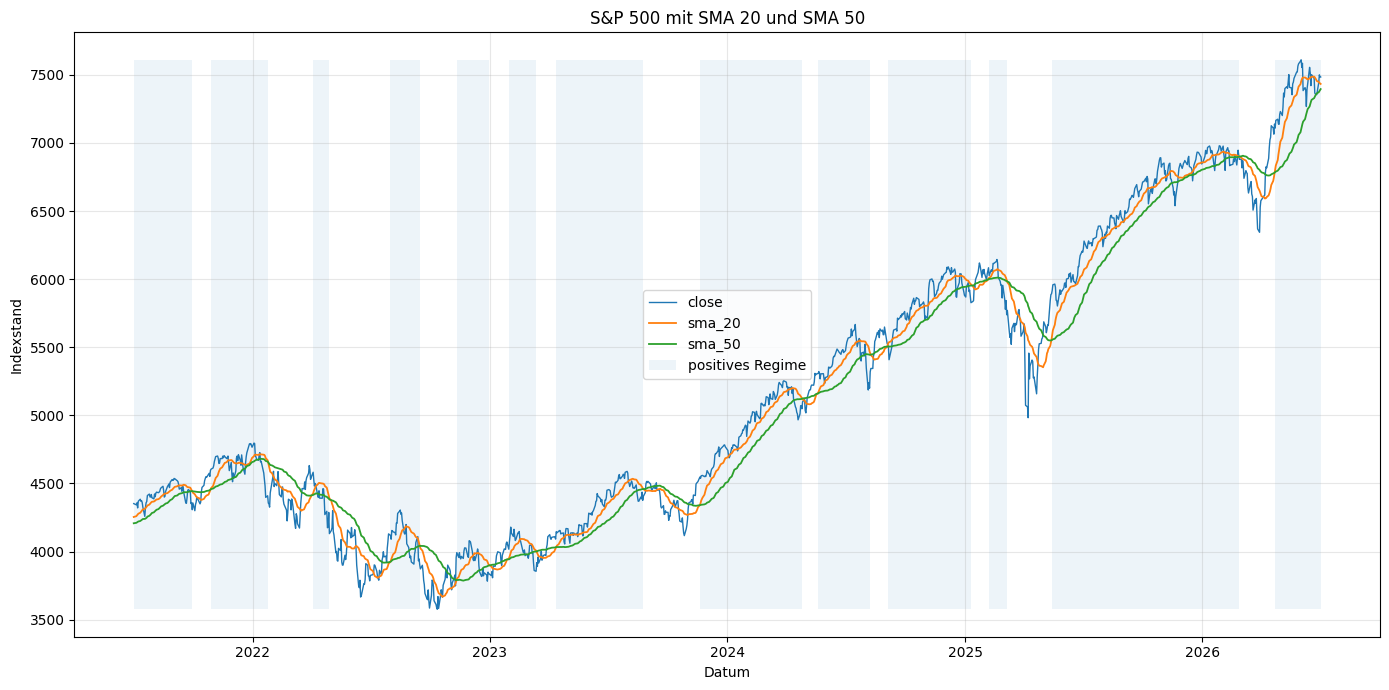

In [41]:
plot_start = analysis_df.index.max() - pd.DateOffset(years=5)

plot_df = analysis_df.loc[analysis_df.index >= plot_start]

ax = plot_df[
    ["close", "sma_20", "sma_50"]
].plot(
    figsize=(14, 7),
    linewidth=1.2,
)

ax.set_title("S&P 500 mit SMA 20 und SMA 50")
ax.set_xlabel("Datum")
ax.set_ylabel("Indexstand")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

plot_df = analysis_df.loc[
    analysis_df.index >= plot_start
].copy()

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    plot_df.index,
    plot_df["close"],
    label="close",
    linewidth=1.0,
)

ax.plot(
    plot_df.index,
    plot_df["sma_20"],
    label="sma_20",
    linewidth=1.3,
)

ax.plot(
    plot_df.index,
    plot_df["sma_50"],
    label="sma_50",
    linewidth=1.3,
)

positive_regime = plot_df["regime"] == "positiv"

ax.fill_between(
    plot_df.index,
    plot_df["close"].min(),
    plot_df["close"].max(),
    where=positive_regime,
    alpha=0.08,
    label="positives Regime",
)

ax.set_title("S&P 500 mit SMA 20 und SMA 50")
ax.set_xlabel("Datum")
ax.set_ylabel("Indexstand")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Der SMA 20 reagiert schneller auf kurzfristige Kursbewegungen als der SMA 50. In ausgeprägten Aufwärtsphasen liegt der SMA 20 überwiegend über dem SMA 50. Bei stärkeren Abwärtsbewegungen fällt der SMA 20 schneller und kann den SMA 50 von oben nach unten kreuzen. In Seitwärts- oder Übergangsphasen liegen beide Durchschnitte enger beieinander und es können häufigere Regimewechsel auftreten.

In [42]:
plot_df["regime_change"] = (
    plot_df["regime"] != plot_df["regime"].shift(1)
)

print(
    "Regimewechsel im dargestellten Zeitraum:",
    plot_df["regime_change"].sum()
)

Regimewechsel im dargestellten Zeitraum: 25
